In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import math
import flystar
from mpl_toolkits.axes_grid1 import make_axes_locatable

import pickle as pickle
import pdb

from scipy.spatial import cKDTree as KDT
from matplotlib.patches import Rectangle
from numpy.polynomial.polynomial import polyfit
from scipy.stats import norm, tstd
from astropy.table import * 
from astropy.modeling import models, fitting
from flystar import match, transforms, plots, align, starlists
from flystar.starlists import StarList
from flystar.startables import StarTable
from astropy.table import Table, Column, vstack
from scipy.stats import gaussian_kde, kde
import seaborn as sns
import copy
import os 

In [4]:
# Reading in matched GC star catalog
fits ='catalogs/dr2/jwst_init_NRCB.fits'
catalog = Table.read(fits, format='fits')
catalog.columns

csv = 'rc-magnitudes.csv'
df = pd.read_csv(csv)

In [5]:
def get_csv_matches(filt1, region1, filt2, region2):
    # Define a base column name for each filter
  # For NRCB1, this will be 'F115W', 'F212N', etc.
    
    # Map region to the correct suffix
    region_map = {
        'NRCB1': '',
        'NRCB2': '.1',
        'NRCB3': '.2',
        'NRCB4': '.3'
    }

    # Get the suffix based on the region
    suffix1 = region_map.get(region1, '')
    suffix2 = region_map.get(region2, '')

    # Construct the full column names
    column1 = f"{filt1}{suffix1}"  # e.g., 'F115W' or 'F115W.1'
    column2 = f"{filt2}{suffix2}"      # e.g., 'F212N' or 'F212N.1'

    # Get the arrays from the DataFrame
    array1 = df[column1]
    array2 = df[column2]

    return array1, array2

f115w, f212n = get_csv_matches('F115W', 'NRCB1', 'F212N', 'NRCB1')

f115w

0       21.287038
1       24.592848
2       23.556416
3       24.155071
4       24.149847
          ...    
5774          NaN
5775          NaN
5776          NaN
5777          NaN
5778          NaN
Name: F115W, Length: 5779, dtype: float64

In [9]:
def get_all_filts(t):
    """
    Helper function to get filts in a catalog, regardless of
    masking
    """
    nepochs = len(t['filt'][0])

    # Loop through each time entry and get year
    # from a non-masked source
    filt_arr = []
    for ii in range(nepochs):
        filt_col = t['filt'][:,ii]

        good = np.where(t['x'][:,ii].mask == False)[0]
        if len(good) > 0:
            filt_arr.append(t['filt'][good[0],ii])
        else:
            filt_arr.append(np.nan)
       

    filt_arr = np.array(filt_arr)
   
    return filt_arr

def get_all_dets(t): 
    """
    Helper function to get detectors in a catalog, regardless of
    masking
    """
    nepochs = len(t['det'][0])

    # Loop through each time entry and get year
    # from a non-masked source
    det_arr = []
    for ii in range(nepochs):
        det_col = t['det'][:,ii]

        good = np.where(t['x'][:,ii].mask == False)[0]
        if len(good) > 0:
            det_arr.append(t['det'][good[0],ii])
        else:
            det_arr.append(np.nan)

    det_arr = np.array(det_arr)
   
    return det_arr

def get_matches(t, filt1, det1, filt2, det2): 
    filt = get_all_filts(t)
    det = get_all_dets(t)

    idx1 = np.where( (filt == filt1) & (det == det1) ) 
    idx2 = np.where( (filt == filt2) & (det == det2) ) 

    filt_1 = t['m'][:,idx1]
    filt_2 = t['m'][:,idx2]

    filt_1me = t['me'][:,idx1]
    filt_2me = t['me'][:,idx2]
    
    good = np.where( (filt_1.mask == False) & (filt_2.mask == False) )
    m_filt1_match = filt_1[good]
    m_filt2_match = filt_2[good]
    me_filt1_match = filt_1me[good]
    me_filt2_match = filt_2me[good]

    return m_filt1_match, m_filt2_match, me_filt1_match, me_filt2_match

# All NRCBs between F212N and F115W
N1_f115w_vf212n, N1_f212n_vf115w, N1_f115w_vf212n_me, N1_f212n_vf115w_me = get_matches(catalog, 'F115W', 'NRCB1', 'F212N', 'NRCB1')


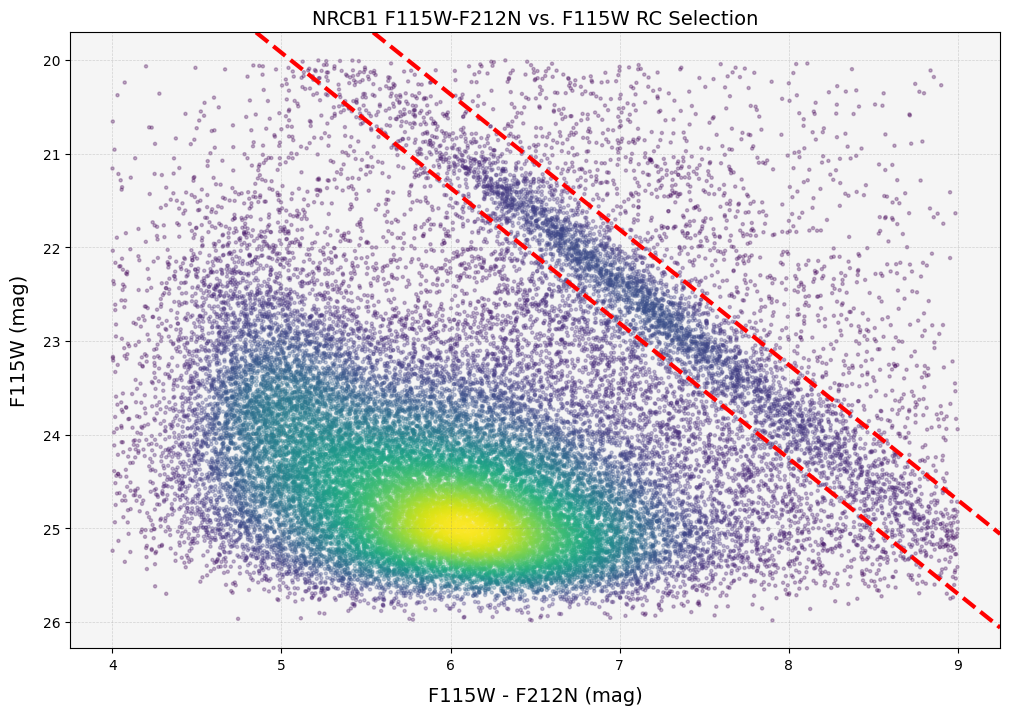

In [31]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 8))
plt.gca().invert_yaxis()

x = np.subtract(N1_f115w_vf212n, N1_f212n_vf115w)
y = N1_f115w_vf212n

mask_x = (x >= 4) & (x <= 9)
mask_y = (y >= 20) & (y <= 26)

mask = mask_x & mask_y 

x = x[mask]
y = y[mask]

xy = np.vstack([x,y])
z = gaussian_kde(xy)(xy)

# Sort the points by density, so that the densest points are plotted last
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]

plt.scatter(x, y, s=5, c=z, alpha=0.3, cmap='viridis')




xy1 = [(6.3, 20.8), (9, 24.7)]	
xy2 = [(6.3, 21.8), (9, 25.7)]

xy11 = [(6.3, 20.8-1.5), (9, 24.7-1.5)]	
xy22 = [(6.3, 21.8+1.5), (9, 25.7+1.5)]



plt.axline(xy1[0], xy1[1], c='r', linestyle='--', linewidth = 3)
plt.axline(xy2[0], xy2[1], c='r', linestyle='--', linewidth = 3)
"""
plt.axline(xy11[0], xy11[1], c='teal', linestyle='--')
plt.axline(xy22[0], xy22[1], c='teal', linestyle='--')
"""

x_range = [4.9, 9.4]
tile_width = (x_range[1]-x_range[0])/15

"""
for i in range(15):
    # Define the x position for each tile
    x_start = x_range[0] + i * tile_width
    x_end = x_start + tile_width
    
    # Define the corresponding y positions based on the RC boundary slopes
    # Interpolate y_start and y_end based on the teal boundaries (xy11 and xy22)
    y_start = xy11[0][1] + (x_start - xy11[0][0]) * (xy11[1][1] - xy11[0][1]) / (xy11[1][0] - xy11[0][0])
    y_end = xy22[0][1]-0.35 + (x_end - xy22[0][0]) * (xy22[1][1] - xy22[0][1]) / (xy22[1][0] - xy22[0][0])
    
    # Draw the tile as a filled rectangle with transparency
    plt.fill_betweenx([y_start, y_end], x_start, x_end, color='r', alpha=0.1, linewidth=1)
"""


# Background color and grid lines
plt.gca().set_facecolor('#f5f5f5')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

# Plot data points with transparency



# Labels and title with a custom font and size
plt.xlabel("F115W - F212N (mag)", fontsize=14, labelpad=10)
plt.ylabel("F115W (mag)", fontsize=14, labelpad=10)
plt.title("NRCB1 F115W-F212N vs. F115W RC Selection", fontsize=14)
plt.savefig("/Users/devaldeliwala/research/muLab/paper/plots/JV-J.png", dpi=300)


# Show plot
plt.show()


### Using the RC stars from a well-defined CMD to find the RC stars in a less-defined CMD
---

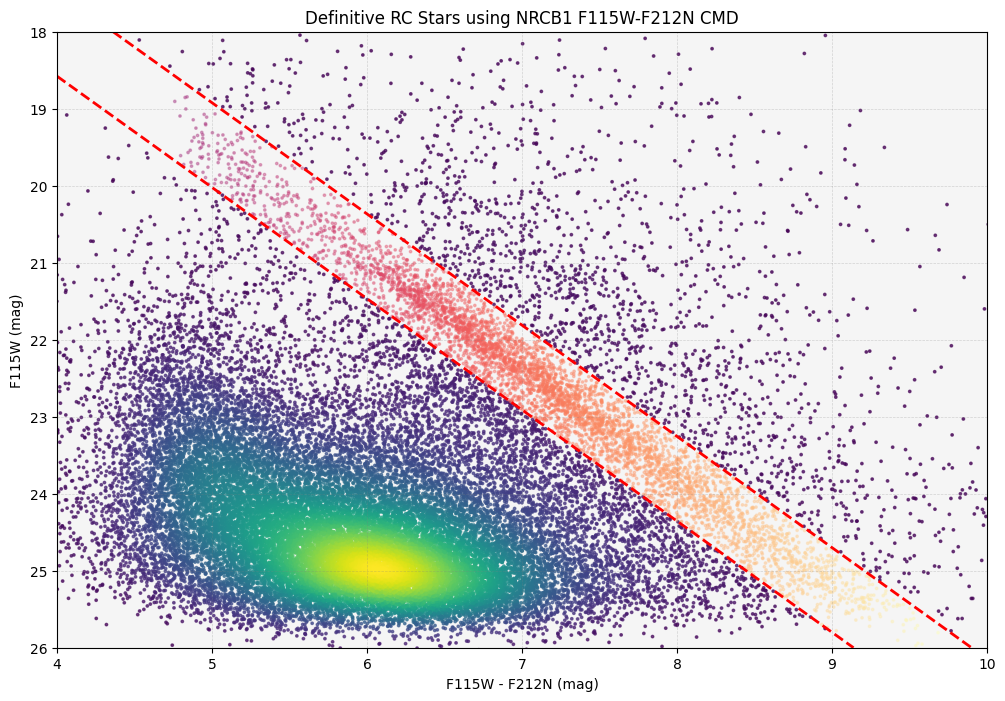

In [25]:
fig, axis = plt.subplots(1, 1, figsize = (12, 8))
plt.gca().set_facecolor('#f5f5f5')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
plt.ylim(18, 26)

x = np.subtract(N1_f115w_vf212n, N1_f212n_vf115w)
y = N1_f115w_vf212n



plt.gca().invert_yaxis()

xy1 = [(6.3, 20.8), (9, 24.7)]	
xy2 = [(6.3, 21.9), (9, 25.8)]

plt.axline(xy1[0], xy1[1], c = 'r', linestyle='--', linewidth=2)
plt.axline(xy2[0], xy2[1], c = 'r', linestyle='--', linewidth=2)

def slope(xy1,  xy2): 
    m = (xy2[1] - xy1[1])/(xy2[0] - xy1[0])
    b = xy1[1] - m * xy1[0]
    return m,b 

m1, b1 = slope(xy1[0], xy1[1])
m2, b2 = slope(xy2[0], xy2[1])
rc_idxs = np.where((y > (m1 * x + b1)) & (y < (m2 * x + b2)))
not_rc_idxs = np.delete(np.arange(len(x)), rc_idxs)


xrc = x[rc_idxs]
yrc = y[rc_idxs]

x_main = x[not_rc_idxs]
y_main = y[not_rc_idxs]

xy = np.vstack([x_main, y_main])
z = gaussian_kde(xy)(xy)

plt.scatter(x_main, y_main, c=z, cmap = 'viridis', s = 3, alpha = 0.7)


norm = plt.Normalize(vmin=min(xrc), vmax=max(xrc))  # Normalize to F115W-F212N range
plt.scatter(xrc, yrc, c = xrc, cmap = "magma", s = 3, alpha = 0.4)

plt.xlabel('F115W - F212N (mag)')
plt.ylabel('F115W (mag)')
plt.title('Definitive RC Stars using NRCB1 F115W-F212N CMD')

plt.xlim(4, 10)

plt.savefig("/Users/devaldeliwala/research/muLab/paper/plots/rc_selection.png", dpi=300)


# getting red clump indices from other regions
full_indices = np.where(np.isin(catalog['m'], N1_f115w_vf212n[rc_idxs]))[0]
N1_F323_mag = catalog[full_indices]['m'][:, 9]
N1_F212_mag = catalog[full_indices]['m'][:, 4]



In [ ]:
color_map = plt.cm.magma


N1_f212n_v323n, N1_f323n_vf212n, N1_f212n_vf323n_me, N1_f323n_vf212n_me = get_matches(catalog, 'F212N', 'NRCB1', 'F323N', 'NRCB5')


plt.subplots(1, 1, figsize = (12, 8))
plt.gca().invert_yaxis()
plt.gca().set_facecolor('#f5f5f5')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

plt.scatter(np.subtract(N1_F212_mag, N1_F323_mag), N1_F323_mag, c=xrc, cmap = 'magma', s = 5)
plt.xlabel('F212N-F323N (mag)')
plt.ylabel('F323N (mag)')
plt.title('NRCB1 F212N - F323N vs. F323N')

plt.subplots(1, 1, figsize = (12, 8))
plt.gca().invert_yaxis()
plt.gca().set_facecolor('#f5f5f5')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

plt.scatter(np.subtract(N1_F212_mag, N1_F323_mag), N1_F212_mag, c=xrc, cmap = 'magma', s = 5)
plt.xlabel('F212N-F323N (mag)')
plt.ylabel('F212N (mag)')
plt.title('NRCB1 F212N - F323N vs. F212N')


In [10]:
df = pd.DataFrame({
    'F115W': N1_F115_mag,
    'F212N': N1_F212_mag,
    'F323N': N1_F323_mag,
    'F405N': N1_F405_mag
}).to_csv('NRCB1-rcmags.csv')

### Rectangular Riemann Slope Determination
---

We define a rectanguar cutoff to extract the stars roughly in the area of the Red Clump Bar

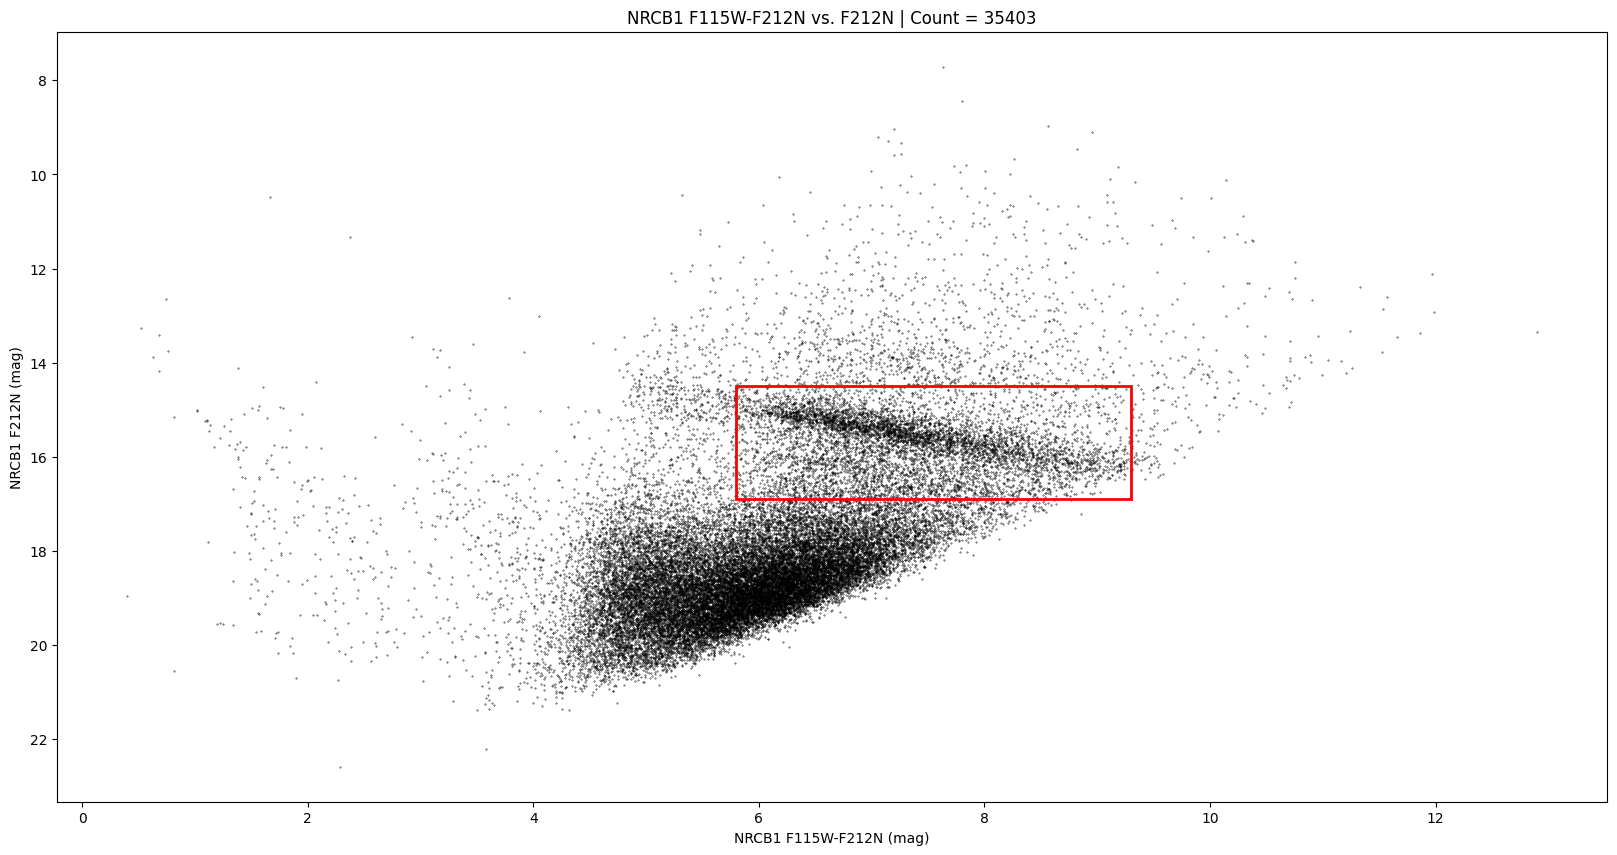

In [11]:
fig, axis = plt.subplots(1,1, figsize = (20, 10))

x = np.subtract(N1_f115w_vf212n, N1_f212n_vf115w) # color
y = N1_f212n_vf115w

plt.scatter(x, y, c = 'k', s = 0.1)

plt.xlabel('NRCB1 F115W-F212N (mag)')
plt.ylabel('NRCB1 F212N (mag)')
plt.title(f'NRCB1 F115W-F212N vs. F212N | Count = {len(x)}')
plt.gca().invert_yaxis()

lower_x = 5.8
lower_y = 14.5
width = 3.5
height = 2.4

cutoff = Rectangle((lower_x, lower_y), width, height, facecolor = (1, 0, 0, 0), lw = 2, ec = (1, 0, 0, 1))
axis.add_patch(cutoff)

Now we extract the stars within the cutoff and find their mag-values from the original catalogs. Easy enough.

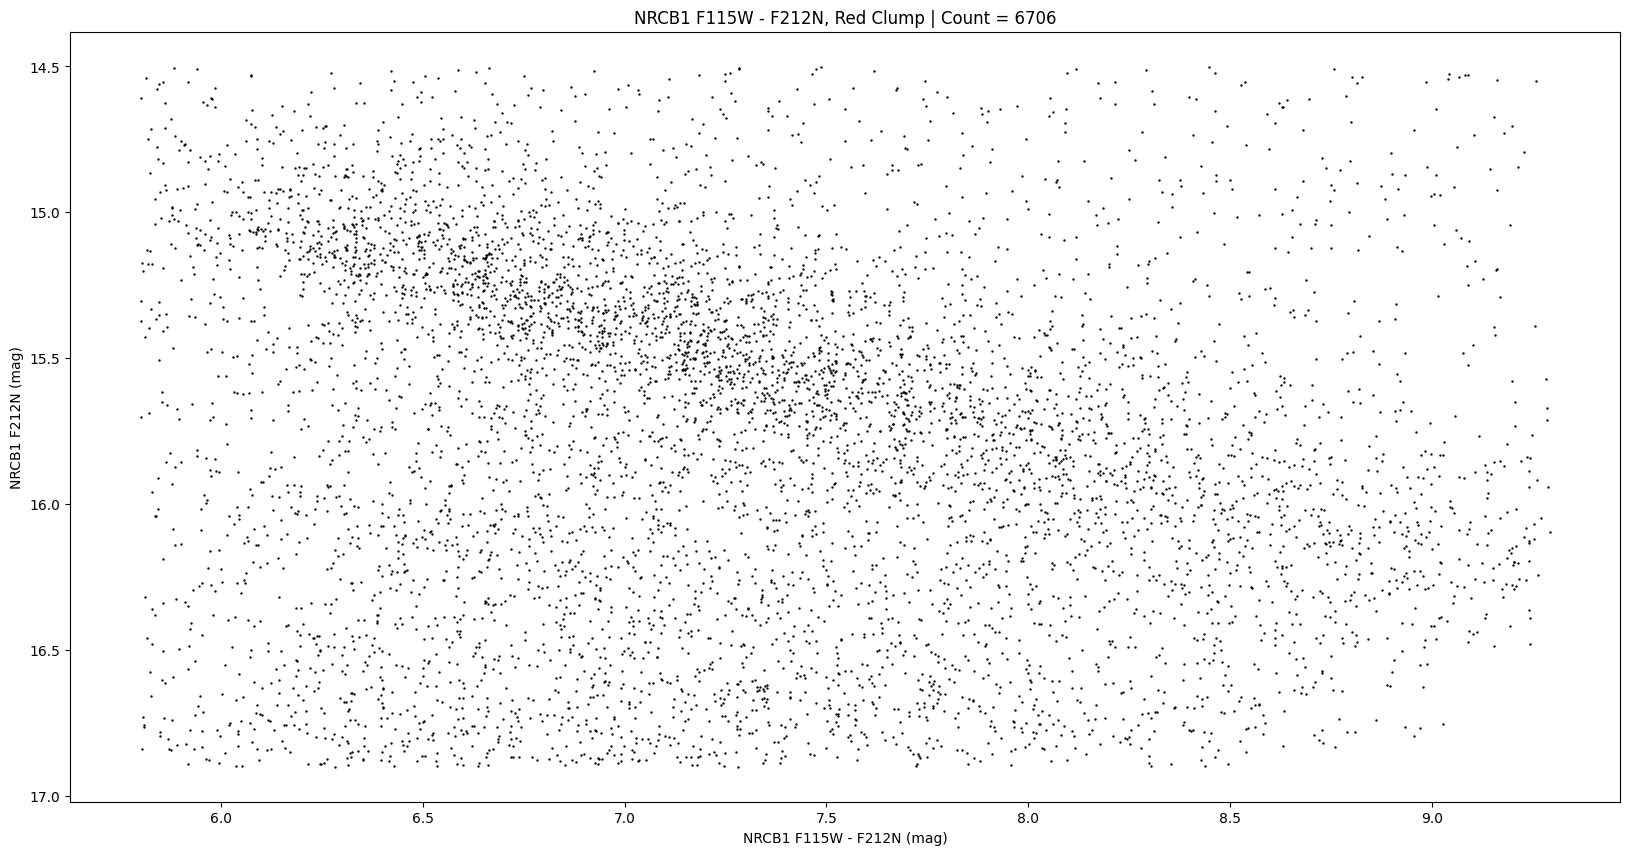

In [12]:
idxs = np.where( (x >= lower_x) & (x < lower_x + width) & 
                 (y >= lower_y) & (y < lower_y + height)
               ) # indices of stars from original catalog within rectangular cutoff
x = x[idxs]
y = y[idxs]

fig, axis = plt.subplots(1, 1, figsize = (20, 10)) 

plt.scatter(x, y, c = 'k', s = 0.5)

plt.xlabel('NRCB1 F115W - F212N (mag)')
plt.ylabel('NRCB1 F212N (mag)')
plt.title(f'NRCB1 F115W - F212N, Red Clump | Count = {len(x)}')
plt.gca().invert_yaxis()

Our goal is now to write an algorithm to divide this Red Clump region into `n` subregions. We afterwards store the indices and mags of stars in each region in a `n x 2` dimensional array. 

In [13]:
def divide_cutoff(n, lower_left, width, height):
    x, y = lower_left
    dx = width / n
    segment_height = height
    xbins = [] # stores the [leftest x, farthest x]...[ , ] of each subregion
    segments = [] # stores the matplotlib.patches.Rectangle objects for each subregion
                  # purely for plotting & visualization purposes
    
    for i in range(n):
        segments.append(Rectangle((x + i * dx, y), dx, segment_height, 
                                  facecolor = (1, 0, 0, 0), lw = 2, ec = (1, 0, 0, 1)
                                 )
                       )
        xbins.append([x + i * dx, x + i * dx + dx])
        
    return segments, xbins

def extract_stars(n, filt1, filt2, filt1name, filt2name, lower_left, width, height, show_plot, verbose): 
    # based on a filt1 - filt2 vs. filt2 CMD
    # xbins stores the [leftest x, farthest x]...[ , ] of each subregion
    # y_range is (lower_y, upper_y) range of cutoff
    # show_plot = Boolean, whether you want to see plot of subregions or not

    x = np.subtract(filt1, filt2)
    y = filt2

    lowerx, lower_y = lower_left
    upper_y = lower_y + height

    count = 0
    idxs = [] # (n x 2) array storing indices of stars in each subregion
    filt1_mag = [] # temporarily stores mag values of an individual subregion
    filt2_mag = [] # for plotting purposes

    segments, xbins = divide_cutoff(n, lower_left, width, height)

    for i in range(len(xbins)): 
        good = np.where((x >= xbins[i][0]) & (x < xbins[i][1]) & 
                       (y >= lower_y) & (y <= upper_y)) # extract indices of stars within each subregion
        
        idxs.append([good])
        filt1_mag.append([filt1[good]])
        filt2_mag.append([filt2[good]])
        
    if show_plot:
        colors = plt.cm.jet(np.linspace(0,1,len(filt1_mag))) # iterate through different colors
        fig, axis = plt.subplots(1, 1, figsize = (20, 10))
        
        for i in range(len(filt1_mag)): 
            plt.scatter(np.subtract(filt1_mag[i], filt2_mag[i]), filt2_mag[i], color = colors[i], s = 0.5)
            count += len(filt1_mag[i][0])

        plt.xlabel(f' {filt1name} - {filt2name} (mag)')
        plt.ylabel(f' {filt2name} (mag)')
        plt.title(f' {filt1name} - {filt2name} vs. {filt2name} | Count = {count} (mag)')
        plt.gca().invert_yaxis()

    # storing filt1 and filt2 magnitudes in DataFrame object for cleanliness
    # each row corresponds to each subregion left to right
    df1 = pd.DataFrame({f'{filt1name}': filt1_mag})
    df2 = pd.DataFrame({f'{filt2name}': filt2_mag})
    df = pd.concat([df1, df2], axis = 1)

    # shedding useless indices
    for i in range(len(df)): 
        df[filt1name][i] = df[filt1name][i][0]
        df[filt2name][i] = df[filt2name][i][0]

    if verbose: 
        display(df)

    return df, idxs

/var/folders/38/q4k6mt054znfh_g97c8zyx1w0000gn/T/ipykernel_80506/3110221038.py:66: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[filt1name][i] = df[filt1name][i][0]
/var/folders/38/q4k6mt054znfh_g97c8zyx1w0000gn/T/ipykernel_80506/31102210

,NRCB1 F115W,NRCB1 F212N
0,"[21.133247855276487, 21.209368046840957, 22.48...","[15.232747260367056, 15.229690841414211, 16.65..."
1,"[21.287037571435107, 21.180158042896043, 21.13...","[15.290123065844103, 15.12756861623474, 15.062..."
2,"[21.035405981324935, 23.058228038033004, 22.73...","[14.843207487972375, 16.738471293100186, 16.42..."
3,"[22.342796360786526, 21.68495675955359, 21.838...","[15.819527957342386, 15.210113721309197, 15.37..."
4,"[22.12913213549933, 21.826843623457947, 22.115...","[15.430431172008284, 15.154872681341583, 15.42..."
5,"[22.29168243244831, 22.4863890369997, 21.74401...","[15.486590561271559, 15.54190170458699, 14.792..."
6,"[22.589887960017705, 22.897151463771106, 22.64...","[15.537444743632076, 15.847241677810324, 15.60..."
7,"[22.783503049719094, 22.786616746034206, 22.78...","[15.490149572097367, 15.555930468927844, 15.61..."
8,"[23.10051324326361, 23.474436099242578, 22.811...","[15.621850082649559, 16.01916242934733, 15.296..."
9,"[23.882994378425757, 24.317287929274514, 23.66...","[16.27666668191906, 16.58068198170033, 15.9371..."


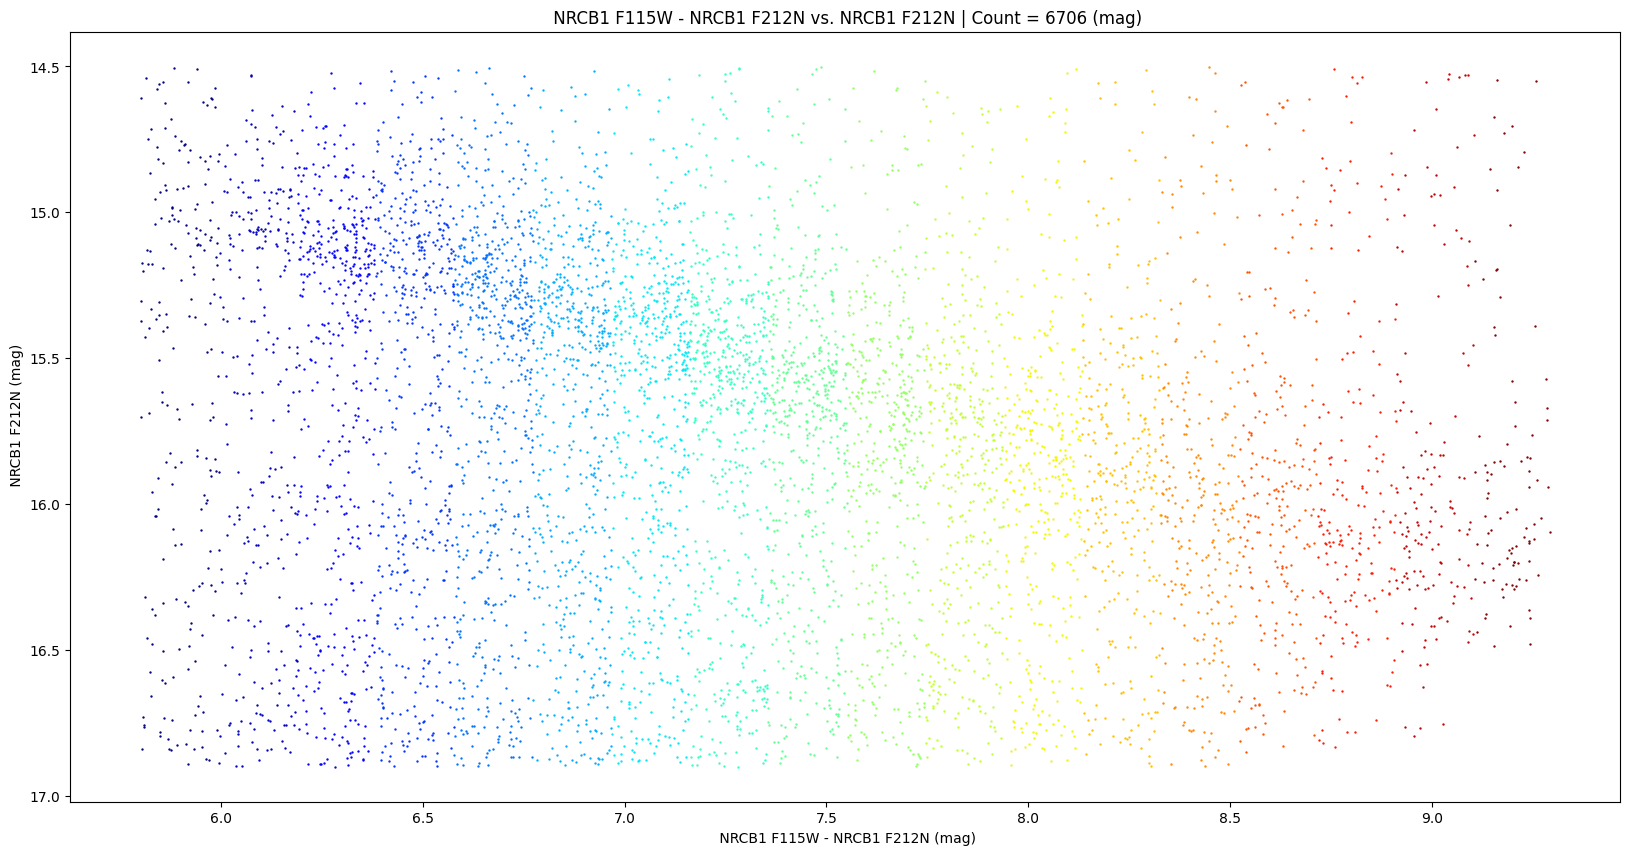

In [14]:
starlist, idxs = extract_stars(n = 18, filt1 = N1_f115w_vf212n, filt2 = N1_f212n_vf115w, 
                     filt1name = 'NRCB1 F115W', filt2name = 'NRCB1 F212N', 
                     lower_left = (lower_x, lower_y), width = width, height=height, 
                     show_plot = True, verbose = True
                    )

### Time for Curve Fitting

- Generate histograms of each subregion
- Implement Preliminary `scipy.stats.norm` to determine rough std and mean
- Implement Scipy Compound `scipy.models.Gaussian1D` + `scipy.models.Linear1D`
- Iterate through varying amplitudes for the`Gaussian1D model` until the returned parameters make sense
- Iterate through generated histograms until the error on the mean $$ \varepsilon = \frac{\sigma}{\sqrt{N}}$$ is minimized
- Return the mean mag in color space and mean color value
- Plot mean mag vs. mean color -- the slope should be the same as the Red Clump Bar

In [15]:
def optimize_bin(data, data_name, show_plot, verbose): 
    # find the number of bins in a histogram that minimizes the error_on_mean for given data
    
    mu, std = norm.fit(data) # preliminary mean and standard deviation from scipy.stats
    std = tstd(data, limits = (mu - 0.4, mu + 0.4))
    amplitude_works = False
    error_bin_amplitude_mean_std = []

    for i in range(8, 20): 
        
        amplitude_works = False
        j = 10
        count = 0
        
        while not amplitude_works:
            
            bin_heights, bin_borders = np.histogram(data, bins = i)
            bin_widths = np.diff(bin_borders)
            bin_centers = bin_borders[:-1] + bin_widths / 2
    
            t_gaussian = models.Gaussian1D(j, mu, std)
            t_linear = models.Linear1D(100, 100)
            t_compound = t_gaussian + t_linear
    
            filt_t = fitting.LevMarLSQFitter()
            t = filt_t(t_compound, bin_centers, bin_heights)

            if t.stddev_0.value > 0.1 and t.amplitude_0.value < 500 and t.amplitude_0.value > 0: # testing for if the fit works
                amplitude_works = True
                error_on_mean = t.stddev_0.value / math.sqrt(len(data))
                error_bin_amplitude_mean_std.append([error_on_mean, i, t.amplitude_0.value, t.mean_0.value, t.stddev_0.value])
            
            j += 20
            count += 1
            
            if count > 5: 
                amplitude_works = True
    
        if show_plot: 
            fig, axis = plt.subplots(1, 1, figsize = (20, 10))
            x_interval_for_fit = np.linspace(bin_borders[0], bin_borders[-1], 10000)
            
            plt.bar(bin_centers, bin_heights, width=bin_widths, label='histogram')
            plt.plot(x_interval_for_fit, t(x_interval_for_fit), label='fit', c='red', linestyle = 'dashed')
            plt.legend()

            plt.xlabel(f'{data_name}')
            plt.ylabel('Frequency')
            plt.title(f" Compound-Fitted Histogram | Mean = {t.mean_0.value.round(3)} | σ = {t.stddev_0.value.round(3)} | Error_on_mean = {(t.stddev_0.value / math.sqrt(len(data))).round(3)}")

    bins = []
    errors = [] 
    amplitudes = []
    means = []
    stds = []
    
    for i in range(len(error_bin_amplitude_mean_std)): # extracting error values into its own array
        bins.append(error_bin_amplitude_mean_std[i][1])
        errors.append(error_bin_amplitude_mean_std[i][0])
        amplitudes.append(error_bin_amplitude_mean_std[i][2])
        means.append(error_bin_amplitude_mean_std[i][3])
        stds.append(error_bin_amplitude_mean_std[i][4])
        
    bins = np.array(bins)
    errors = np.array(errors)
    amplitudes = np.array(amplitudes)
    means = np.array(means)
    stds = np.array(stds)
    
    while means[np.where(errors == errors.min())] > 17: 
        errors = np.delete(errors, np.where(errors == errors.min()))
        means = np.delete(means, np.where(errors == errors.min()))

    min_index = np.where((errors == errors.min())) # determining the # of bins with the smallest error_on_mean
    min_index = min_index[0][0]

    optimized_error = errors[min_index]
    optimized_bin_value = bins[min_index]
    optimized_amplitude = amplitudes[min_index]
    optimized_mean = means[min_index]
    optimized_std = stds[min_index]
    
    if verbose: 

        print(f"{data_name}")
        print(f" Bins |   Error   |  Amplitude  |    Mean    |    Std ")
        print(f"-------------------------------------------------------------")
        print(f" {optimized_bin_value}   |   { optimized_error.round(3):.3f}   |   {optimized_amplitude.round(4):.4f}   |   {optimized_mean.round(3):.3f}   |   {optimized_std.round(3):.3f}  ")
        print(f"")

    return optimized_bin_value, optimized_amplitude, optimized_mean, optimized_error, optimized_std

In [16]:
def generate_hists(starlist, show_hist, verbose, path):

    ax = plt.figure(figsize = (10, 10)).add_subplot(projection = '3d')
    ax.view_init(elev=35, azim=-45, roll=0)
    colors = plt.cm.jet(np.linspace(0,1,len(starlist)))

    ax.set_xlabel(f"{starlist.columns[0]} - {starlist.columns[1]}")
    ax.set_ylabel(f"{starlist.columns[1]}")
    ax.set_zlabel("Frequency")
    ax.zaxis.labelpad=-0.01 # <- change the value here

    optimized_means = []
    optimized_mean_errors = []

    for i in range(len(starlist)): 
        
        ax.scatter(np.subtract(starlist[starlist.columns[0]][i], starlist[starlist.columns[1]][i]), 
                   starlist[starlist.columns[1]][i], 
                   zs = 0, zdir = 'z', label = 'CMD', 
                   color = colors[i], s = 0.3
                  )
        min_x = np.min(np.subtract(starlist[starlist.columns[0]][i], starlist[starlist.columns[1]][i]))

        # fitting 
        optimized_bin_value, optimized_amplitude, optimized_mean, optimized_error, optimized_std = optimize_bin(starlist[starlist.columns[1]][i], 
                                                                                                   starlist.columns[1], 
                                                                                                   show_plot = False, 
                                                                                                   verbose = verbose
        )

        optimized_means.append(optimized_mean)
        optimized_mean_errors.append(optimized_error)
        

        bin_heights, bin_borders = np.histogram(starlist[starlist.columns[1]][i], bins=optimized_bin_value)
        bin_widths = np.diff(bin_borders)
        bin_centers = bin_borders[:-1] + bin_widths / 2
        
        t_gaussian = models.Gaussian1D(optimized_amplitude, optimized_mean, optimized_std)
        t_linear = models.Linear1D(100, 100)
        t_compound = t_gaussian + t_linear
        
        fit_t = fitting.LevMarLSQFitter()
        t = fit_t(t_compound, bin_centers, bin_heights)
        
        x_interval_for_fit = np.linspace(bin_borders[0], bin_borders[-1], 10000)
        
        if show_hist: 
            plt.bar(bin_centers, bin_heights, width=bin_widths, label='histogram', zs = min_x, zdir = 'x', ec = 'k', facecolor = (0,0,0,0))
        
        plt.plot(x_interval_for_fit, t(x_interval_for_fit), label='fit', c=colors[i], zs = min_x, zdir = 'x')
        
        plt.savefig(f"{path}/{starlist.columns[1]}_optimized_with_{len(starlist)}_bins.png")
                
    return optimized_means, optimized_mean_errors

AttributeError: 'Normalize' object has no attribute 'fit'

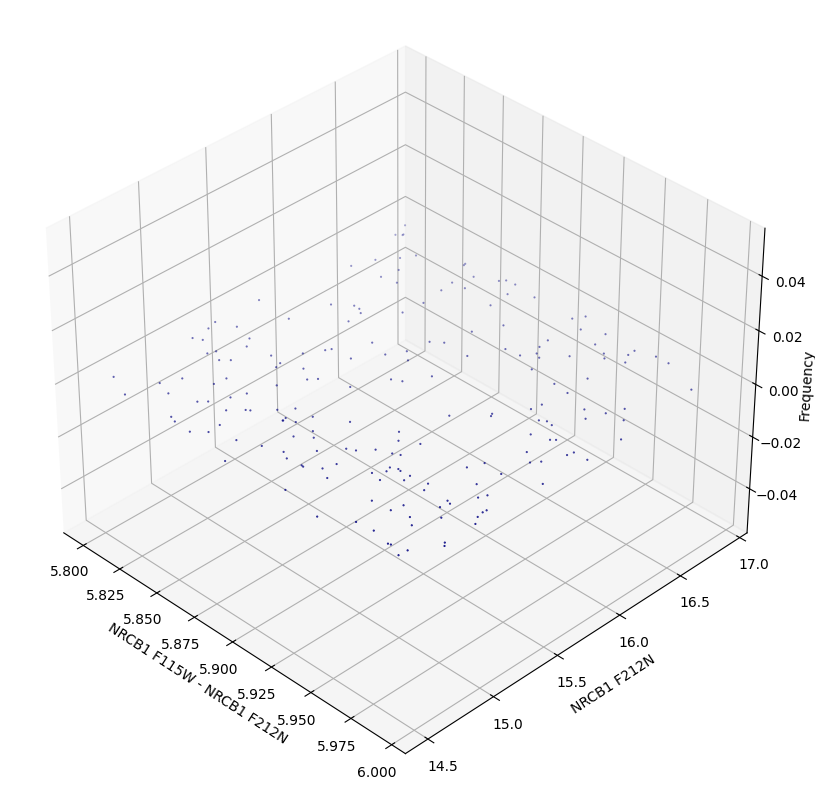

In [17]:
optimized_means, optimized_mean_errors = generate_hists(starlist, show_hist = False, verbose = False, path = "/Users/devaldeliwala/research/work/rc_analysis_plots")

In [ ]:
N1_115_catalog = Table.read("catalogs/dr2/NRCB1_catalog115w.csv").to_pandas()
N1_212_catalog = Table.read("catalogs/dr2/NRCB1_catalog212n.csv").to_pandas()

In [ ]:
df, df2 = N1_115_catalog, N1_212_catalog

x1 = df['x']   # x centroid position of catalog1 stars
y1 = df['y']   # y centroid position of catalog1 stars 
m1 = df['m']   # vega magnitude of catalog1 stars
me1 = df['me'] # error in vega magnitude of catalog1 stars
x2 = df2['x']
y2 = df2['y']
m2 = df2['m']
me2 = df2['me']

In [ ]:
idxs1, idxs2, dr, dm = flystar.match.match(x1, y1, m1, x2, y2, m2, 
                                                  dr_tol = 0.5, dm_tol = 100, 
                                                  verbose = False)

In [ ]:
m1_error, m2_error = me1[idxs1], me2[idxs2]
m1_matched, m2_matched = m1[idxs1], m2[idxs2]

m1_matched = np.array(m1_matched)
m2_matched = np.array(m2_matched)

m_difference = np.subtract(m1_matched, m2_matched)

xy = np.vstack([m_difference, m2_matched])
z = gaussian_kde(xy)(xy)

In [ ]:
print(len(m1_matched))

29513


Making error-weighted color-magnitude diagram.
Generating final pdf.


'Unsharp_hess_F115W_F212N.pickle'

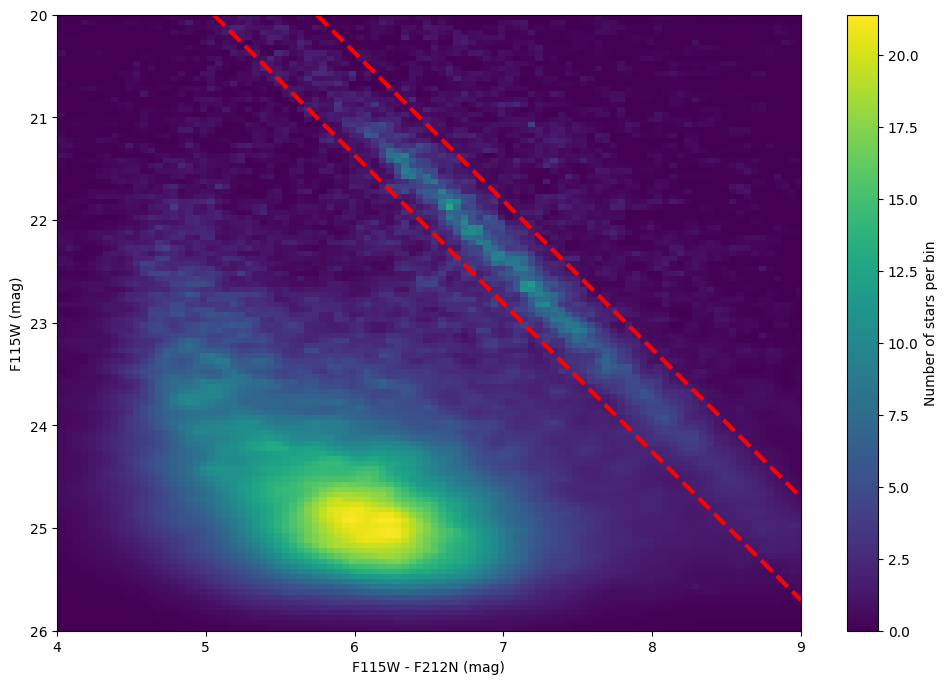

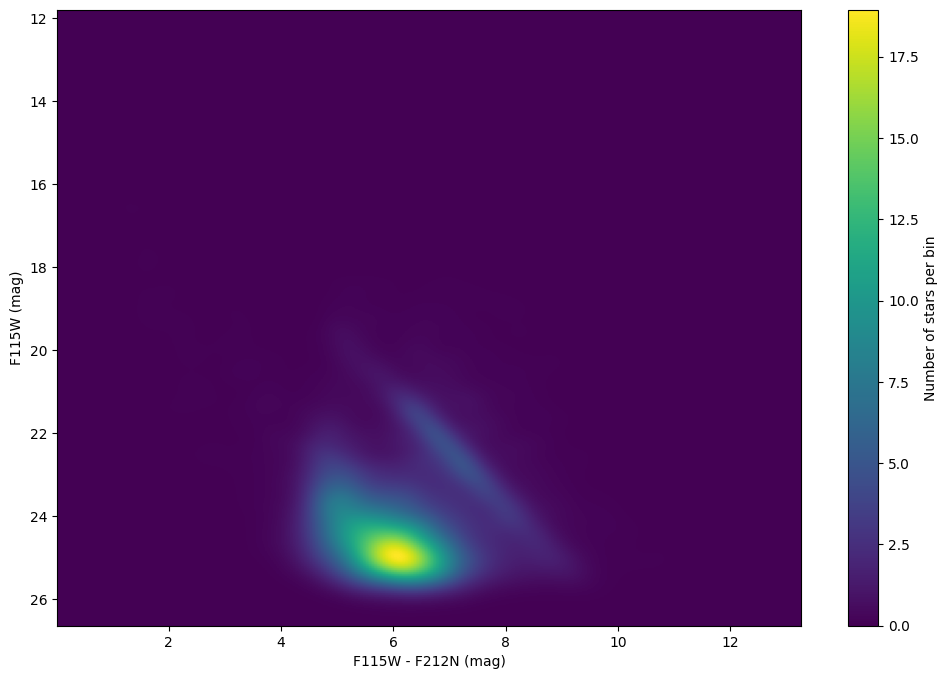

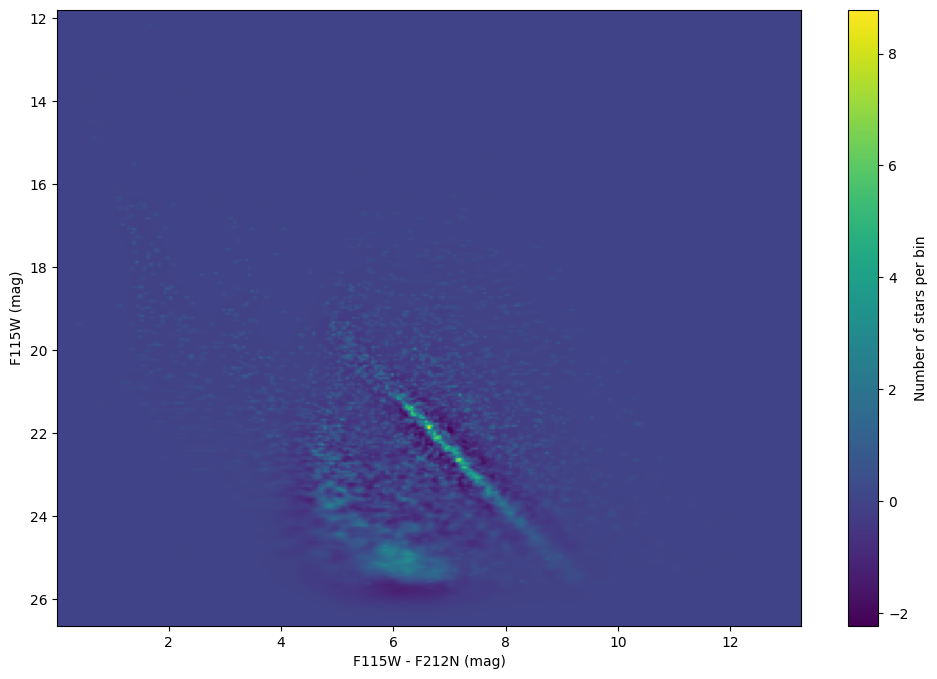

In [33]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import pickle 
import flystar
import copy
import os 

from scipy.spatial import cKDTree as KDT
from numpy.polynomial.polynomial import polyfit
from scipy.stats import norm, tstd, gaussian_kde, kde
from astropy.table import * 
from astropy.convolution import convolve, Gaussian2DKernel
from flystar import match, transforms, plots, align, starlists
from flystar.starlists import StarList
from flystar.startables import StarTable

#not used here
import pdb
import pylab as py

from astropy.modeling import models, fitting
from spisea import synthetic, evolution, atmospheres, reddening, ifmr
from spisea.imf import imf, multiplicity


def unsharp_mask(mag1, mag2, magy, mag1err, mag2err, magyerr,
                    mag1_filt, mag2_filt, magy_filt,
                    magerr_lim_max = 1.0,
                    mask_width = 0.2,
                    binsize_mag = 0.05,
                    binsize_clr = 0.05,
                    fig_dimensions = 'default',
                    hess_extent = None,
                    fig_path = "" , data_path = "", 
                    vmini = None, vmaxi = None,
                    vminf = None, vmaxf = None,
                    recalc = True, verbose = False): 

    """
    Apply the image-sharpening technique unsharp masking to
    the color-magnitude diagram (CMD) of the NSC to show the RC star
    region cleanly. This procedure replicates the one used by De Marchi
    et al, 2016. (https://doi.org/10.1093/mnras/stv2528)

    Makes magy vs. (mag1 - mag2) CMD

    Parameters:
    --------------
    mag1, mag2, magy     : arrays
        Magnitudes in the appropriate filters, in apparent mags

    mag1err, mag2err, magyerr: arrays
        magnitude errors in the appropriate filters

    mag1_filt, mag2_filt, magy_filt: str
        Names of mag1 and mag2 and magy filters

    magerr_lim_max  : float
        Maximum photometric error. Stars with photometric error more than
        magerr_lim_max in trim_err_cols columns will be masked.

    mask_width      : float
        Standard deviation of mask gaussian kernel, in mags;
        for unsharp mask

    binsize_mag     : float
        Size of the bin in magnitudes for the histogram in the CMD
        along the y-axis (filter 2 magnitudes)

    binsize_clr     : float
        Size of the bin in magnitudes for the histogram in the CMD
        along the x-axis (filter 1 - filter 2 magnitudes)

    fig_dimensions  : 'default' or two-element tuple
        Specifies the size of the figures; 'default' produces
        figures of size (10,10)

    hess_extent     : None or four-element array
        Specifies x-limits and y-limits of the hess diagram;
        Should be given in order of [xmin, xmax, ymin, ymax]

    fig_path        : string
        Path to directory that figures will be stored in

    data_path       : string
        Path to directory that data will be stored in

    vmin            : float
        Hess diagram minimum value

    vmax            : float
        Hess diagram maximum value

    clean_catalog   : bool
        Whether to apply photometric error cuts to the
        HST catalog before generating the Hess diagram

    recalc          : bool
        Recalculate modified Hess diagram if it already exists

    """


    unsharp_mask_extent = copy.deepcopy(hess_extent)
    final_cmd_extent = copy.deepcopy(hess_extent)

    outname = 'Unsharp_hess_{0}_{1}.pickle'.format(mag1_filt, mag2_filt)

    mag1 = np.array(mag1)
    mag2 = np.array(mag2)
    magy = np.array(magy)
    mag1err = np.array(mag1err)
    mag2err = np.array(mag2err)
    magyerr = np.array(magyerr)

    if (not os.path.exists(data_path + outname)) or (recalc == True):
        # Clean out stars with large photometric errors and
        # stars not found in relevant filters
        
        good = np.where( (np.isfinite(mag1)) & (np.isfinite(mag2)) &
                        (mag1err <= magerr_lim_max) & (mag2err <= magerr_lim_max) &
                        (magyerr <= magerr_lim_max) &
                        (mag1err > 0) & (mag2err > 0))
        if verbose:
            print('{1} of {0} stars considered'.format(len(mag1), len(good[0])))
        mag1 = np.array(mag1)[good[0]]
        mag2 = np.array(mag2)[good[0]]
        mag1err = np.array(mag1err)[good[0]]
        mag2err = np.array(mag2err)[good[0]]
        magy = np.array(magy)[good[0]]
        magyerr = np.array(magyerr)[good[0]]

        # Compute color: mag1 - mag2
        clr_arr = abs(mag1 - mag2)
        clrerr_arr = np.hypot(mag1err, mag2err)

        # Assign mag2 to be the 'color'
        mag_arr = magy
        magerr_arr = magyerr

        # Define magnitude bin limits and the color bin limits
        # for histograms (include value extremes plus error)
        mag_min = np.min(mag_arr) - np.max(magerr_arr)
        mag_max = np.max(mag_arr) + np.max(magerr_arr)

        clr_min = np.min(clr_arr) - np.max(clrerr_arr)
        clr_max = np.max(clr_arr) + np.max(clrerr_arr)

        # Bins for magnitude array and bins for color array
        bins_mag = np.arange(mag_min, mag_max, binsize_mag)
        bins_clr = np.arange(clr_min, clr_max, binsize_clr)

        #-----------------------------------------------------------------#
        # Construct binned CMD of stars, where each star magnitude
        # is a 2D Guassian of width equal to photometric error
        #-----------------------------------------------------------------#

        print('Making error-weighted color-magnitude diagram.')
        #obs_pdf = np.zeros((len(mag_arr),len(bins_mag)-1,len(bins_clr)-1))
        tmp_obs_pdf = np.zeros((1000,len(bins_mag)-1,len(bins_clr)-1))
        obs_pdf_sum = np.sum(tmp_obs_pdf,axis = 0)

        # Determine the 2D Gaussian distribution of each star
        # in batches
        adjust = 0

        for ii in range(len(mag_arr)):
            # For each bin:
            mag = mag_arr[ii]                      # Magnitude of bin
            magerr = magerr_arr[ii]                # Magnitude error of bin
            clr = clr_arr[ii]                      # Color of bin
            clrerr = clrerr_arr[ii]                # Color error of bin

            # Normal continuous random variable distributions
            mag_var = norm(loc=mag, scale = magerr)
            clr_var = norm(loc=clr, scale = clrerr)

            # Cumulative density functions
            mag_cdf = mag_var.cdf(bins_mag)
            clr_cdf = clr_var.cdf(bins_clr)

            # Probability distributions for bin
            mag_pdf_binned = np.diff(mag_cdf)
            clr_pdf_binned = np.diff(clr_cdf)
            pdf = np.outer(mag_pdf_binned, clr_pdf_binned)

            # Add star to binned CMD array
            tmp_obs_pdf[ii-adjust] = pdf

            if ii% 1000 == 0:
                obs_pdf_sum = obs_pdf_sum + np.sum(tmp_obs_pdf, axis=0)

                # Reset the temporary pdf
                tmp_obs_pdf = np.zeros((1000,len(bins_mag)-1,len(bins_clr)-1))
                adjust += 1000
                if verbose: 
                    print('Done {0} of {1}'.format(ii, len(mag_arr)))

        # Error-weighted CMD, summed over the individual stars. Need to
        # get the contribution from the last set of stars (not even mod1000)
        obs_pdf_sum = obs_pdf_sum + np.sum(tmp_obs_pdf, axis=0)

        # Let's make sure we have the contribution from all stars (within 1 star)
        #assert np.isclose(np.sum(obs_pdf_sum), len(mag1), atol=1)

        #-----------------------------------------------------------------#
        # Plot the observed probability density functions (Hess diagram)  
        #-----------------------------------------------------------------#

        # Limits of the plot; can be specified in the initiation of the
        # function using hess_extent

        if hess_extent == None:
            # If not specified, determine boundaries from color and
            # magnitude histograms
            clr_min = bins_clr[0]
            clr_max = bins_clr[-1]
            mag_min = bins_mag[0]
            mag_max = bins_mag[-1]

            hess_limits = (clr_min, clr_max, mag_max, mag_min)

        else:
            # Use given boundaries
            clr_min = hess_extent[0]
            clr_max = hess_extent[1]
            mag_max = hess_extent[2]
            mag_min = hess_extent[3]

            ind_clr_min = int(np.argmin(np.absolute(bins_clr - clr_min)))
            ind_clr_max = int(np.argmin(np.absolute(bins_clr - clr_max)))

            ind_mag_min = int(np.argmin(np.absolute(bins_mag - mag_min)))
            ind_mag_max = int(np.argmin(np.absolute(bins_mag - mag_max)))

            hess_limits = (bins_clr[ind_clr_min], bins_clr[ind_clr_max],
                                bins_mag[ind_mag_max], bins_mag[ind_mag_min])

        if fig_dimensions == 'default':
            fig_dimensions = (12,8)

        # Initialize figure for unedited Hess diagram
        fig1, ax1 = plt.subplots(1, 1, figsize = fig_dimensions)

        # Plot the Hess diagram
        if hess_extent == None:
            hess_plot = ax1.imshow(obs_pdf_sum, extent = hess_limits,
                                vmin = vmini, vmax = vmaxi)
        else:
            hess_plot = ax1.imshow(obs_pdf_sum[ind_mag_min:ind_mag_max, ind_clr_min:ind_clr_max],
                                        extent = hess_limits,
                                        vmin = vmini, vmax = vmaxi)
            
        # Label plot
        ax1.set_xlabel('{0} - {1} (mag)'.format(mag1_filt, mag2_filt))
        ax1.set_ylabel('{0} (mag)'.format(magy_filt))


        xy1 = [(6.3, 20.8), (9, 24.7)]	
        xy2 = [(6.3, 21.8), (9, 25.7)]

        ax1.axline(xy1[0], xy1[1], c='r', linestyle='--', linewidth =3)
        ax1.axline(xy2[0], xy2[1], c='r', linestyle='--', linewidth=3)
        cbar_hess = plt.colorbar(hess_plot, ax = ax1)
        cbar_hess.set_label('Number of stars per bin')
        ax1.axis('tight')
        plt.xlim(4, 9)
        plt.ylim(26, 20)
        fig1.savefig(fig_path + 'error_weighted_hess_diagram_{0}_{1}_{2}.png'.format(mag1_filt, 
                                                                                        mag2_filt,
                                                                                        magy_filt), dpi=300
                    )

        #-----------------------------------------------------------------#
        # Generate the unsharp mask
        #-----------------------------------------------------------------#
        # Create astropy kernel object of desired width based on the magnitude
        # binsize
        sigma_mask = mask_width / binsize_mag
        gauss = Gaussian2DKernel(sigma_mask)

        # Create mask by convolving gaussian kernel with pdf
        mask = convolve(obs_pdf_sum, gauss)

        #-----------------------------------------------------------------#
        # Plot the unsharp mask
        #-----------------------------------------------------------------#

        # Limits of the plot; can be specified in the initiation of the
        # function using unsharp_mask_extent

        if unsharp_mask_extent == None:
            clr_min = bins_clr[0]
            clr_max = bins_clr[-1]
            mag_min = bins_mag[0]
            mag_max = bins_mag[-1]

            unsharp_mask_limits = (clr_min, clr_max, mag_max, mag_min)
        else:
            clr_min = unsharp_mask_extent[0]
            clr_max = unsharp_mask_extent[1]
            mag_max = unsharp_mask_extent[2]
            mag_min = unsharp_mask_extent[3]

            ind_clr_min = int(np.argmin(np.absolute(bins_clr - clr_min)))
            ind_clr_max = int(np.argmin(np.absolute(bins_clr - clr_max)))

            ind_mag_min = int(np.argmin(np.absolute(bins_mag - mag_min)))
            ind_mag_max = int(np.argmin(np.absolute(bins_mag - mag_max)))

            unsharp_mask_limits = (bins_clr[ind_clr_min], bins_clr[ind_clr_max],
                                        bins_mag[ind_mag_max], bins_mag[ind_mag_min])

        # Plot values
        if fig_dimensions == 'default':
            fig_dimensions = (20,10)

        # Initialize plot
        fig2, ax2 = plt.subplots(1, 1, figsize = fig_dimensions)

        if unsharp_mask_extent == None:
            mask_plot = ax2.imshow(mask, extent = unsharp_mask_limits,
                            vmin = vmini, vmax = vmaxi)
        else:
            mask_plot = ax2.imshow(mask[ind_mag_min:ind_mag_max,
                                ind_clr_min:ind_clr_max],
                                extent = unsharp_mask_limits,
                                vmin = vmini, vmax = vmaxi)

        ax2.set_xlabel('{0} - {1} (mag)'.format(mag1_filt, mag2_filt))
        ax2.set_ylabel('{0} (mag)'.format(magy_filt))
        cbar_mask = plt.colorbar(mask_plot, ax = ax2)
        cbar_mask.set_label('Number of stars per bin')
        ax2.axis('tight')

        fig2.savefig(fig_path + 'unsharp_mask_{0}_{1}_{2}.png'.format(mag1_filt,
                                                                        mag2_filt,
                                                                        magy_filt)
                    )

        #-----------------------------------------------------------------#
        # Subtract mask from original binned CMD (Hess diagram) to get
        # the final, sharpened CMD
        #-----------------------------------------------------------------#

        print('Generating final pdf.')
        pdf_final = obs_pdf_sum - mask

        #-----------------------------------------------------------------#
        # Plot the final, sharpened binned CMD
        #-----------------------------------------------------------------#

        # Limits of the plot; can be specified in the initiation of the
        # function using final_cmd_extent

        if final_cmd_extent == None:
            clr_min = bins_clr[0]
            clr_max = bins_clr[-1]
            mag_min = bins_mag[0]
            mag_max = bins_mag[-1]

            final_cmd_limits = (clr_min, clr_max,mag_max, mag_min)

        else:
            clr_min = final_cmd_extent[0]
            clr_max = final_cmd_extent[1]
            mag_max = final_cmd_extent[2]
            mag_min = final_cmd_extent[3]

            ind_clr_min = int(np.argmin(np.absolute(bins_clr - clr_min)))
            ind_clr_max = int(np.argmin(np.absolute(bins_clr - clr_max)))

            ind_mag_min = int(np.argmin(np.absolute(bins_mag - mag_min)))
            ind_mag_max = int(np.argmin(np.absolute(bins_mag - mag_max)))

            final_cmd_limits = (bins_clr[ind_clr_min], bins_clr[ind_clr_max],
                                    bins_mag[ind_mag_max], bins_mag[ind_mag_min])

        # Plot values
        if fig_dimensions == 'default':
            fig_dimensions = (20,10)

        # Initialize plot
        fig3, ax3 = plt.subplots(1, 1, figsize = fig_dimensions)

        if final_cmd_extent == None:
            final_pdf_plot = ax3.imshow(pdf_final, extent = final_cmd_limits,
                                    vmin = vminf, vmax = vmaxf)
        else:
            final_pdf_plot = ax3.imshow(pdf_final[ind_mag_min:ind_mag_max,
                                ind_clr_min:ind_clr_max],
                                extent = final_cmd_limits,
                                vmin = vminf, vmax = vmaxf)
        ax3.set_xlabel('{0} - {1} (mag)'.format(mag1_filt, mag2_filt))
        ax3.set_ylabel('{0} (mag)'.format(magy_filt))
        cbar_final = plt.colorbar(final_pdf_plot, ax = ax3)
        cbar_final.set_label('Number of stars per bin')
        ax3.axis('tight')

        fig3.savefig(fig_path + 'unsharp_final_cmd_{0}_{1}_{2}.png'.format(mag1_filt,
                                                                            mag2_filt,
                                                                            magy_filt)
                    )

        # Save the final probability distribution function data as a
        # pickle file

        _out = open(data_path + outname, 'wb')

        pickle.dump(pdf_final, _out)
        pickle.dump(bins_mag, _out)
        pickle.dump(bins_clr, _out)

        _out.close

    return outname

def save_hist(hist, magbins, clrbins, outName):
    
    """
    Helper function to save the histogram bins
    and 2D Hess diagram (hist) with name
    outName

    Parameters:
    _____________
    hist    : 2D numpy array
        2D image-sharpened probability density
        function

    magbins : 1D numpy array
        bin boundaries for magnitudes

    clrbins : 1D numpy array
        bin boundaries for colors

    outName : string
        path + filename of the pickle file
        of the histogram

    """

    _out = open(outName, 'wb')

    pickle.dump(hist, _out)
    pickle.dump(magbins, _out)
    pickle.dump(clrbins, _out)

    _out.close()

    return

unsharp_mask(N1_f115w_vf212n, N1_f212n_vf115w, N1_f115w_vf212n, N1_f115w_vf212n_me, N1_f212n_vf115w_me, N1_f115w_vf212n_me, 'F115W', 'F212N', 'F115W')